In [49]:
!pip install -qU langgraph langchain langchain-core ddgs pygraphviz boto3 langchain-aws arxiv

In [ ]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated
import operator
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, ToolMessage
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_community.tools import DuckDuckGoSearchRun
from IPython.display import Markdown, display


In [51]:
search = DuckDuckGoSearchRun()

In [52]:
from langchain_community.tools import ArxivQueryRun
from langchain_community.utilities import ArxivAPIWrapper

# Create the Arxiv API wrapper
arxiv_wrapper = ArxivAPIWrapper()

# Create the Arxiv tool
arxiv_tool = ArxivQueryRun(api_wrapper=arxiv_wrapper)

In [53]:
class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]

In [54]:
class Agent:

    def __init__(self, model, tools, system=""):
        self.system = system
        graph = StateGraph(AgentState)
        graph.add_node("llm", self.call_model)
        graph.add_node("action", self.take_action)
        graph.add_conditional_edges(
            "llm",
            self.exists_action,
            {True: "action", False: END}
        )
        graph.add_edge("action", "llm")
        graph.set_entry_point("llm")
        self.graph = graph.compile()
        self.tools = {t.name: t for t in tools}
        self.model = model.bind_tools(tools)

    def exists_action(self, state: AgentState):
        result = state['messages'][-1]
        return len(result.tool_calls) > 0

    def call_model(self, state: AgentState):
        messages = state['messages']
        if self.system:
            messages = [SystemMessage(content=self.system)] + messages
        message = self.model.invoke(messages)
        return {'messages': [message]}

    def take_action(self, state: AgentState):
        tool_calls = state['messages'][-1].tool_calls
        results = []
        for t in tool_calls:
            print(f"Calling: {t}")
            if not t['name'] in self.tools:      # check for bad tool name from LLM
                print("\n ....bad tool name....")
                result = "bad tool name, retry"  # instruct LLM to retry if bad
            else:
                result = self.tools[t['name']].invoke(t['args'])
            results.append(ToolMessage(tool_call_id=t['id'], name=t['name'], content=str(result)))
        print("Back to the model!")
        return {'messages': results}

In [55]:
import boto3
import json

bedrock = boto3.client('bedrock-runtime', region_name='us-east-1')

request_body = {
    'messages': [
        {
            'role': 'user',
            'content': [{'text': 'What is AWS bedrock AgentCore?'}]
        }
    ],
    'inferenceConfig': {
        'maxTokens': 512,
        'temperature': 0.7
    }
}

response = bedrock.invoke_model(
    modelId='us.amazon.nova-2-lite-v1:0',
    body=json.dumps(request_body)
)

response_body = json.loads(response['body'].read())
content_list = response_body["output"]["message"]["content"]
# Extract the first text block
text_block = next((item for item in content_list if "text" in item), None)
if text_block is not None:
   #♣ print(text_block["text"])
    display(Markdown(text_block["text"]))

### **AWS Bedrock AgentCore**

As of the current information available (up to 2024), **AWS Bedrock AgentCore** is **not an officially documented or released service** by Amazon Web Services (AWS). It’s possible that you may have encountered this term in one of the following contexts:

---

## 🔍 Possible Explanations

### 1. **Internal or Pre-Release Terminology**
- AWS frequently develops and tests new features internally before releasing them publicly. **AgentCore** might be an **internal code name**, **internal service**, or **pre-release component** related to AWS Bedrock’s agent-building capabilities.
- AWS Bedrock is a service that allows developers to **build and scale generative AI applications** using foundation models from Amazon and third-party providers.
- In 2023–2024, AWS introduced **Agents in Bedrock**, allowing users to create **AI agents** that can perform tasks using natural language inputs. **AgentCore** could be a backend or core engine powering those agents, but it has not been officially named or documented.

---

### 2. **Misinterpretation or Typo**
- You may have seen a term that sounds similar, such as:
  - **AWS Bedrock Agents**
  - **AWS Agentic Workflows**
  - **Amazon Bedrock Agent Runtime**
- These are real, documented components related to building AI agents on Bedrock.

---

### 3. **Third-Party or Community Projects**
- Some developers or third-party tools may have created custom frameworks or wrappers around AWS Bedrock agents and named them something like **AgentCore**. This would be **community-driven**, not an AWS service.

---

## ✅ What You Might Be Referring To

If you're asking about **AWS Bedrock Agents**, here's a brief overview:

### **AWS Bedrock Agents (Official Service)**

**AWS Bedrock Agents** is a feature of Amazon Bedrock that allows developers to:
- **Build AI agents** that understand user inputs and execute actions (like querying a database, calling APIs, or generating responses).
- **Automate complex workflows** using natural language.
- Integrate with **AWS services**, **custom APIs**, and **knowledge bases**.

#### Key Features:
| Feature | Description |
|--------|-------------|
| **Agent Creation** | Define agents with instructions, action groups, and integration points. |
| **Natural Language Understanding** | Agents parse user intent and determine appropriate actions. |
| **Action Groups** | Predefined or custom APIs that agents can invoke (e.g.,

In [56]:
from langchain_aws import ChatBedrock

# Replace the OpenAI model with AWS Nova Lite
model = ChatBedrock(
    model_id="us.amazon.nova-2-lite-v1:0",  
    model_kwargs={
        "temperature": 0,
        "top_p": 1,
        "max_tokens": 1000,
    }
)

In [75]:
prompt = """You are a smart research assistant. Use the search engine to look up information. \
You are allowed to make multiple calls (either together or in sequence). \
Only look up information when you are sure of what you want. \
If you need to look up some information before asking a follow up question, you are allowed to do that!
"""

#test_agent = Agent(model, [search, arxiv_tool], system=prompt)

test_agent = Agent(model, [search, arxiv_tool], system=prompt)


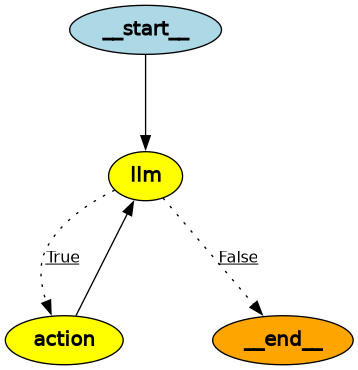

In [76]:
from IPython.display import Image

Image(test_agent.graph.get_graph().draw_png())

In [59]:
messages = [HumanMessage(content="We are February 2026, What is the latest AI news from MIT?")]
result = test_agent.graph.invoke({"messages": messages})

Calling: {'name': 'duckduckgo_search', 'args': {'query': 'latest AI news from MIT 2026'}, 'id': 'tooluse_Q73Buyjpo351ZqqVuE4NA1', 'type': 'tool_call'}
Back to the model!


In [83]:
result

{'messages': [HumanMessage(content='We are February 2026, search the latest AI architectural diagrams released by AWS, add the links', additional_kwargs={}, response_metadata={}),
  AIMessage(content=[{'type': 'tool_use', 'name': 'duckduckgo_search', 'input': {'query': 'latest AI architectural diagrams released by AWS 2026'}, 'id': 'tooluse_uhlzEh9Z94CxbmdYVYS9fM'}], additional_kwargs={}, response_metadata={'ResponseMetadata': {'RequestId': '955f77a0-7efb-4943-a234-63ea9b152889', 'HTTPStatusCode': 200, 'HTTPHeaders': {'date': 'Wed, 04 Feb 2026 00:38:41 GMT', 'content-type': 'application/json', 'content-length': '354', 'connection': 'keep-alive', 'x-amzn-requestid': '955f77a0-7efb-4943-a234-63ea9b152889'}, 'RetryAttempts': 0}, 'stopReason': 'tool_use', 'metrics': {'latencyMs': [377]}, 'model_provider': 'bedrock_converse', 'model_name': 'us.amazon.nova-2-lite-v1:0'}, id='lc_run--019c2616-48f4-7e43-a8e8-1ee30633dcf2-0', tool_calls=[{'name': 'duckduckgo_search', 'args': {'query': 'latest A

In [61]:
display(Markdown(result['messages'][-1].content))

Here are some of the latest AI news highlights from MIT as of early 2026:

### **Key AI Trends and Developments from MIT in Early 2026**

1. **MIT Sloan Management Review (SMR) Insights (January 6, 2026)**  
   - **AI Trends for 2026**: Columnists Thomas H. Davenport and Randy Bean identified five major trends:
     - **Deflation of the AI "bubble"**: Economic impacts from cooling down overhyped AI expectations.
     - **Growth of AI "factory" infrastructure**: Organizations are building scalable systems to support AI adoption.
     - **Shift to generative AI as an organizational resource**: Focus is moving from individual tools to enterprise-wide generative AI applications.
     - **Progress toward agentic AI**: Development of AI systems that can act autonomously to deliver value, despite challenges.

2. **MIT Technology Review's 2026 Breakthrough Technologies List (January 27, 2026)**  
   - AI was featured among the **10 Breakthrough Technologies** expected to shape the future. The list highlights transformative innovations across AI, biotech, space, and energy.

3. **Expert Predictions for 2026 (January 1, 2026)**  
   - Reporter Anabelle Nicoud interviewed experts in AI, security, and quantum computing to explore where technology—especially AI—will take us in 2026.

### **What to Watch in AI at MIT in 2026**
- **Agentic AI**: Continued progress toward systems that can plan, execute, and adapt independently.
- **Generative AI at Scale**: Enterprise adoption and integration of generative models into business workflows.
- **Ethical and Economic Impacts**: Addressing the fallout from the "AI bubble" and ensuring responsible deployment.

These updates reflect MIT’s ongoing leadership in tracking and analyzing AI’s evolving role in technology and society. For deeper insights, you can explore the original articles from [MIT Sloan Review](https://sloanreview.mit.edu) and [MIT Technology Review](https://www.technologyreview.com). 

Let me know if you'd like summaries of any specific articles or trends!

In [62]:
messages = [HumanMessage(content="We are February 2026, What is the latest AI research paper released?")]
result = test_agent.graph.invoke({"messages": messages})

Calling: {'name': 'arxiv', 'args': {'query': 'AI research paper'}, 'id': 'tooluse_IpEhRR71LzkaYVQSSy7zik', 'type': 'tool_call'}
Back to the model!


In [63]:
display(Markdown(result['messages'][-1].content))

The latest AI research paper released in February 2026 is titled **"Competing Visions of Ethical AI: A Case Study of OpenAI"**. It was published on **January 23, 2026**, and authored by **Melissa Wilfley, Mengting Ai, and Madelyn Rose Sanfilippo**.

### Summary of the Paper:
The paper investigates how OpenAI frames ethical AI discourse in its public communications. It analyzes how terms like *"ethics," "safety," "alignment,"* and related concepts are used across different audiences (general public vs. academic). The study uses a combination of **qualitative content analysis** and **computational NLP methods** to track changes in rhetoric over time.

#### Key Findings:
- **Safety and risk** dominate OpenAI’s public discourse, with little use of academic ethics frameworks or vocabularies typically employed by advocacy groups or researchers.
- The paper highlights potential **ethics-washing** practices within the industry, where ethical language may be used more for PR than substantive governance.

The authors have made their code and data publicly available on GitHub for reproducibility: [https://github.com/famous-blue-raincoat/AI_Ethics_Discourse](https://github.com/famous-blue-raincoat/AI_Ethics_Discourse).

If you'd like further details or insights from this paper, let me know!

In [67]:
messages = [HumanMessage(content="We are February 2026, search the latest AI architectural diagrams released by AWS, add the links")]
result = test_agent.graph.invoke({"messages": messages})

Calling: {'name': 'duckduckgo_search', 'args': {'query': 'latest AI architectural diagrams released by AWS 2026'}, 'id': 'tooluse_uhlzEh9Z94CxbmdYVYS9fM', 'type': 'tool_call'}
Back to the model!
Calling: {'name': 'duckduckgo_search', 'args': {'query': 'AWS AI architectural diagrams 2026 official release'}, 'id': 'tooluse_EaSC7o7iDoVKP1WVS6SA0M', 'type': 'tool_call'}
Back to the model!
Calling: {'name': 'duckduckgo_search', 'args': {'query': 'AWS AI architecture diagrams official documentation 2026'}, 'id': 'tooluse_wVqkrKVeY2XtBopy4medKm', 'type': 'tool_call'}
Back to the model!
Calling: {'name': 'duckduckgo_search', 'args': {'query': 'AWS AI architecture diagrams pdf 2026'}, 'id': 'tooluse_higWDpg4WazXqHIdiOyfxD', 'type': 'tool_call'}
Back to the model!
Calling: {'name': 'duckduckgo_search', 'args': {'query': 'AWS Generative AI architecture diagrams 2026'}, 'id': 'tooluse_bdHoXIyB5oFFLoZpN3xWv1', 'type': 'tool_call'}
Back to the model!


In [69]:
result

{'messages': [HumanMessage(content='We are February 2026, search the latest AI architectural diagrams released by AWS, add the links', additional_kwargs={}, response_metadata={}),
  AIMessage(content=[{'type': 'tool_use', 'name': 'duckduckgo_search', 'input': {'query': 'latest AI architectural diagrams released by AWS 2026'}, 'id': 'tooluse_uhlzEh9Z94CxbmdYVYS9fM'}], additional_kwargs={}, response_metadata={'ResponseMetadata': {'RequestId': '955f77a0-7efb-4943-a234-63ea9b152889', 'HTTPStatusCode': 200, 'HTTPHeaders': {'date': 'Wed, 04 Feb 2026 00:38:41 GMT', 'content-type': 'application/json', 'content-length': '354', 'connection': 'keep-alive', 'x-amzn-requestid': '955f77a0-7efb-4943-a234-63ea9b152889'}, 'RetryAttempts': 0}, 'stopReason': 'tool_use', 'metrics': {'latencyMs': [377]}, 'model_provider': 'bedrock_converse', 'model_name': 'us.amazon.nova-2-lite-v1:0'}, id='lc_run--019c2616-48f4-7e43-a8e8-1ee30633dcf2-0', tool_calls=[{'name': 'duckduckgo_search', 'args': {'query': 'latest A